In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("titanic_data_updated.csv")

print(f"Total potential features : {df.shape[1]}")
print(f"Total sample data : {df.shape[0]}")

Total potential features : 12
Total sample data : 891


In [5]:
# df.head(10)
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
512,513,yes,first,"McGough, Mr. James Robert",male,36.0,0,0,PC 17473,26.2875,E25,S
555,556,no,first,"Wright, Mr. George",male,62.0,0,0,113807,26.5500,NaN,S
276,277,no,third,"Lindblom, Miss. Augusta Charlotta",female,45.0,0,0,347073,7.7500,NaN,S
224,225,yes,first,"Hoyt, Mr. Frederick Maxfield",male,38.0,1,0,19943,90.0000,C93,S
410,411,no,third,"Sdycoff, Mr. Todor",male,NaN,0,0,349222,7.8958,NaN,S
513,514,yes,first,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54.0,1,0,PC 17603,59.4000,NaN,C
707,708,yes,first,"Calderhead, Mr. Edward Pennington",male,42.0,0,0,PC 17476,26.2875,E24,S
400,401,yes,third,"Niskanen, Mr. Juha",male,39.0,0,0,STON/O 2. 3101289,7.9250,NaN,S
97,98,yes,first,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
450,451,no,second,"West, Mr. Edwy Arthur",male,36.0,1,2,C.A. 34651,27.7500,NaN,S


## Messing Values

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Checking Duplicates

In [7]:
df.duplicated().sum()

# right now here not duplicated value

# if found duplicated value found. deleted it 

df.drop_duplicates(inplace=True)



In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [9]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


## Uni variate Analysis (Category)

<Axes: xlabel='Survived', ylabel='count'>

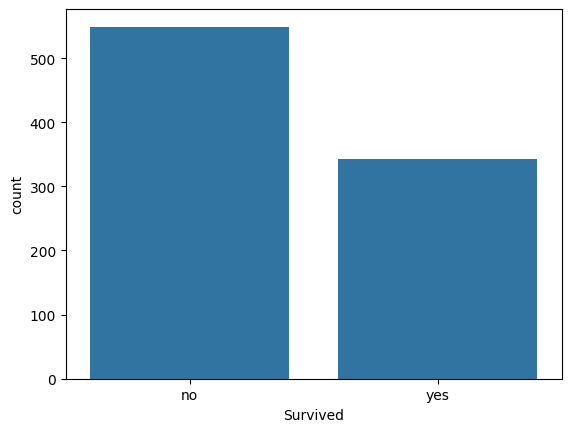

In [10]:
sns.countplot(data=df, x=df['Survived'])

In [11]:
(df['Survived'].value_counts() / len(df)) * 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

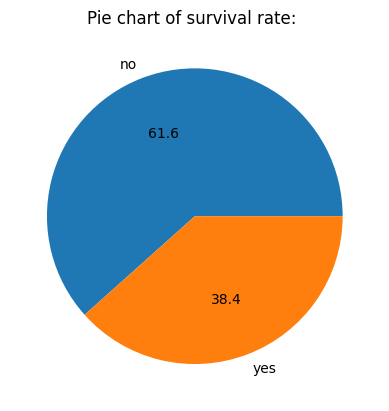

In [12]:
survived_count = df["Survived"].value_counts()

survived_label = df["Survived"].unique()

plt.pie(survived_count, labels=survived_label, autopct='%1.1f')

plt.title("Pie chart of survival rate: ")

plt.show()



<Axes: xlabel='Pclass', ylabel='count'>

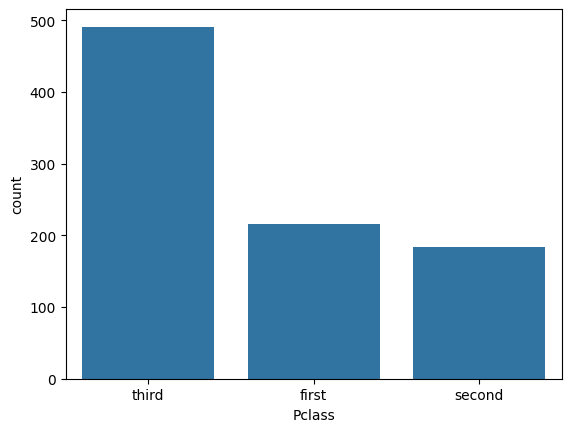

In [13]:
sns.countplot(data=df, x=df['Pclass'])

In [14]:
(df['Pclass'].value_counts() / len(df)) * 100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

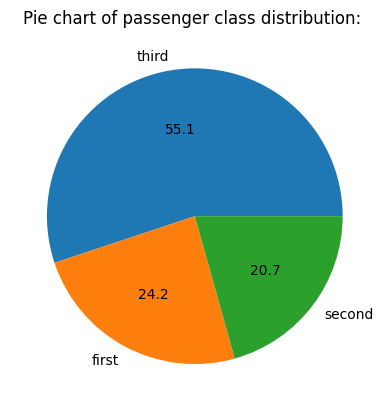

In [15]:
Pclass_count = df["Pclass"].value_counts()

Pclass_label = df["Pclass"].unique()

plt.pie(Pclass_count, labels=Pclass_label, autopct='%1.1f')

plt.title("Pie chart of passenger class distribution: ")

plt.show()

<Axes: xlabel='Sex', ylabel='count'>

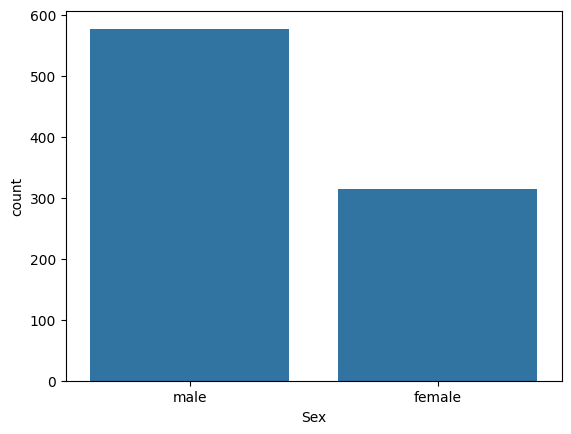

In [16]:
sns.countplot(data=df, x=df['Sex'])

In [17]:
(df['Sex'].value_counts() / len(df)) * 100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

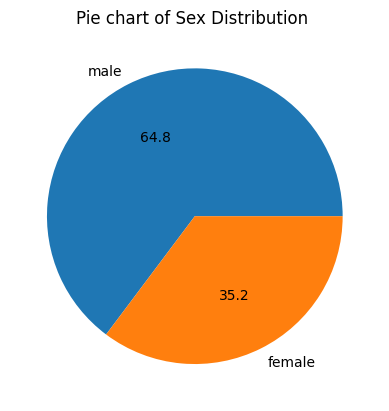

In [18]:
Sex_count = df["Sex"].value_counts()

Sex_label = df["Sex"].unique()

plt.pie(Sex_count, labels=Sex_label, autopct='%1.1f')

plt.title("Pie chart of Sex Distribution ")

plt.show()

<Axes: xlabel='Embarked', ylabel='count'>

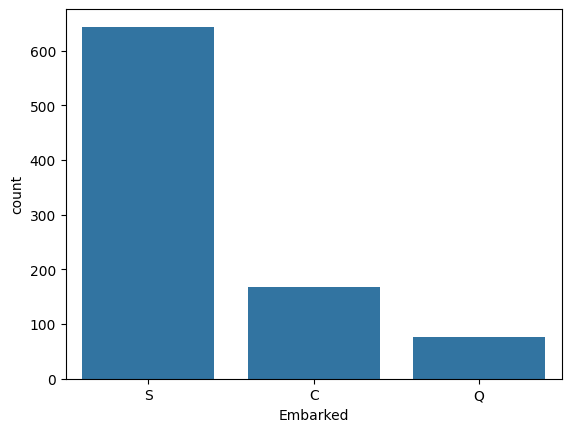

In [19]:
sns.countplot(data=df, x=df['Embarked'])

In [20]:
(df['Embarked'].value_counts() / len(df)) * 100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

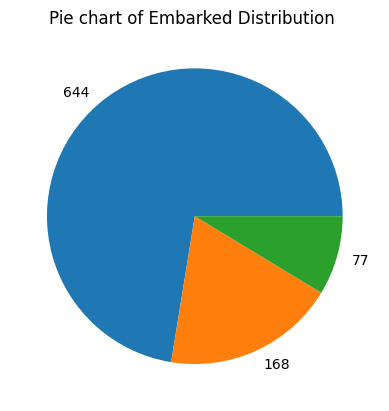

In [21]:
Embarked_count = df["Embarked"].value_counts()

Embarked_label = df["Embarked"].unique()

plt.pie(Embarked_count, labels=Embarked_count)

plt.title("Pie chart of Embarked Distribution ")

plt.show()

Text(0, 0.5, 'Frequency')

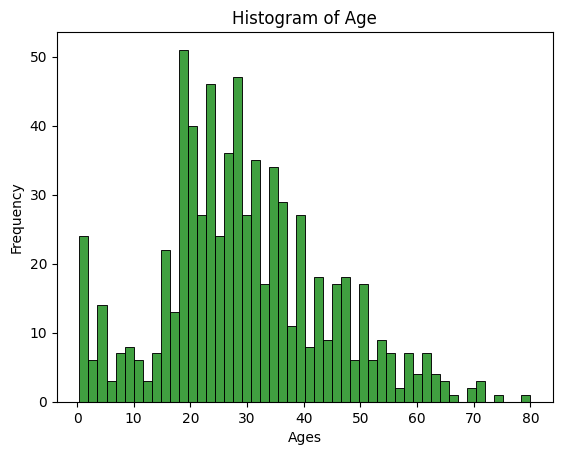

In [22]:
sns.histplot(data=df['Age'], bins=50, color="green")

plt.title("Histogram of Age")
plt.xlabel("Ages")
plt.ylabel("Frequency")

Text(0, 0.5, 'Probabilty distribution')

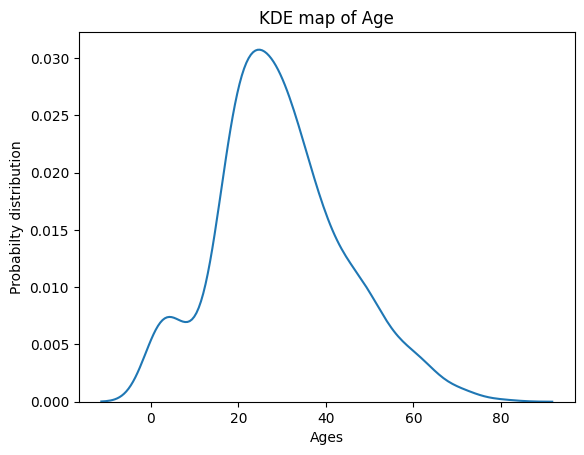

In [23]:
sns.kdeplot(df['Age'])

plt.title("KDE map of Age")
plt.xlabel("Ages")

plt.ylabel("Probabilty distribution")

Text(0, 0.5, 'Frequency')

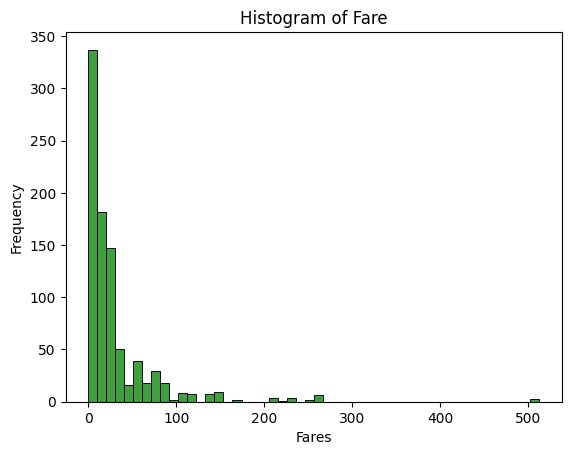

In [24]:
sns.histplot(data=df['Fare'], bins=50, color="green")

plt.title("Histogram of Fare")
plt.xlabel("Fares")
plt.ylabel("Frequency")

Text(0, 0.5, 'Probabilty distribution')

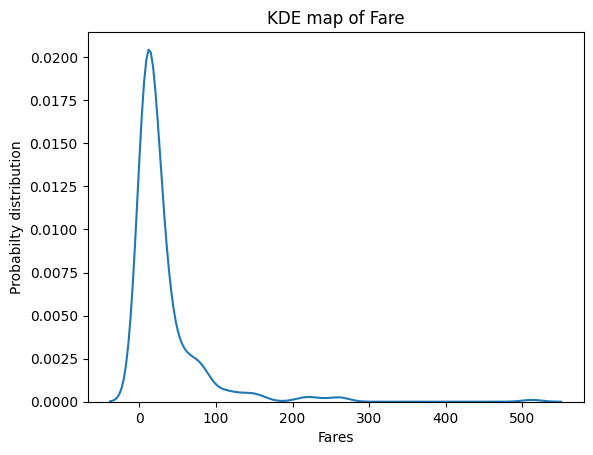

In [25]:
sns.kdeplot(df['Fare'])

plt.title("KDE map of Fare")
plt.xlabel("Fares")

plt.ylabel("Probabilty distribution")

<Axes: ylabel='Fare'>

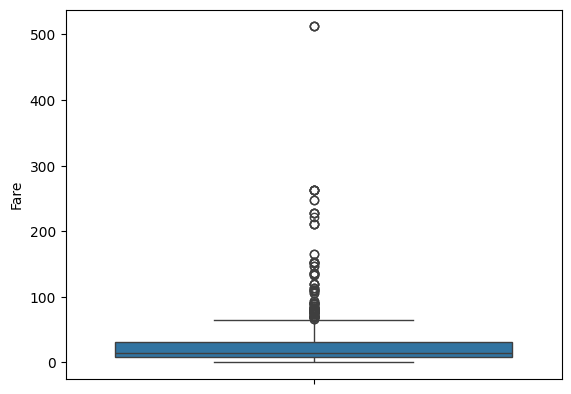

In [26]:
sns.boxplot(df['Fare'])

## Multi Variate Analysis

<Axes: xlabel='Sex', ylabel='count'>

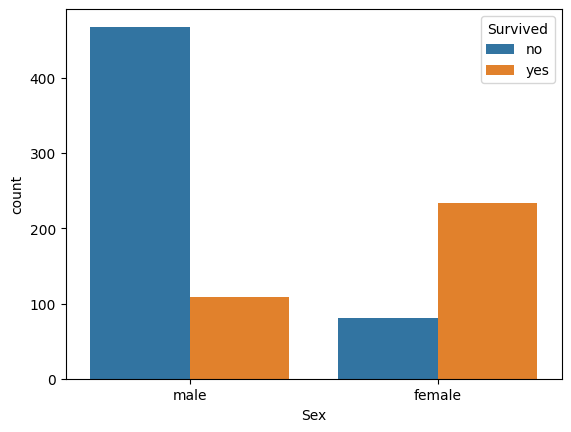

In [27]:
sns.countplot(x=df['Sex'], hue=df['Survived'])

In [28]:
gender_split = df.groupby("Sex")['Survived'].value_counts(normalize=True)

print(gender_split)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

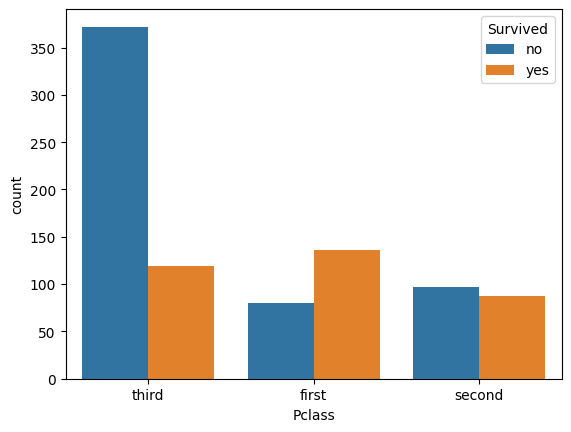

In [29]:
sns.countplot(x=df['Pclass'], hue=df['Survived'])

In [30]:
pclass_split = df.groupby("Pclass")['Survived'].value_counts(normalize=True)

print(pclass_split)

Pclass  Survived
first   yes         0.629630
        no          0.370370
second  no          0.527174
        yes         0.472826
third   no          0.757637
        yes         0.242363
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='Fare'>

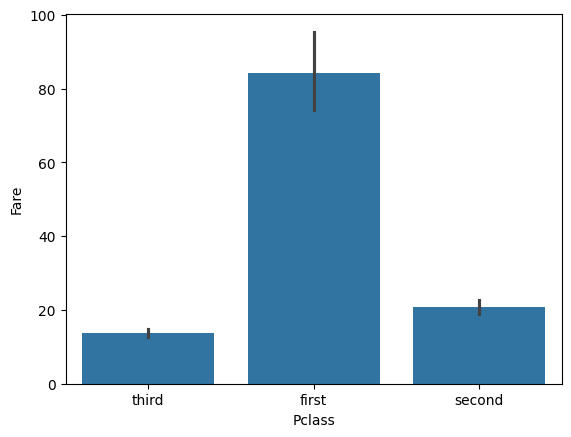

In [31]:
sns.barplot(x=df['Pclass'], y=df['Fare'])

<Axes: xlabel='Survived', ylabel='Age'>

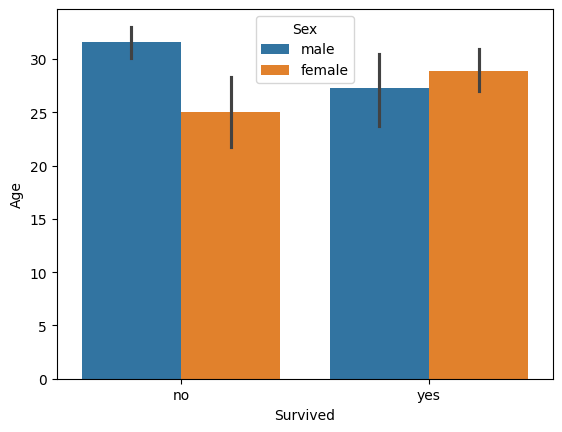

In [32]:
sns.barplot(x=df['Survived'], y=df['Age'], hue=df['Sex'])

In [34]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Titanic Data Profiling Report")

profile.to_file("titanic_data_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 372.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]